# 🥋 AI Karate Sensei — Professional Data Analysis
## Exploratory Data Analysis (EDA)

> **Run this notebook BEFORE training any models.**  
> It gives you a full statistical and visual audit of the extracted feature CSVs.

---

### What this notebook covers
| Section | Description |
|---------|-------------|
| **1** | Dataset Overview & Class Balance |
| **2** | Per-Clip Frame Count Distribution |
| **3** | Feature Summary Statistics |
| **4** | Feature Value Distributions |
| **5** | Correlation Heatmap (Angles) |
| **6** | PCA — Separability Visualisation |
| **7** | Temporal Signal Samples per Class |
| **8** | Data Quality Report |

## 📦 0. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ── Aesthetics ────────────────────────────────────────────────────────────────
PALETTE  = {'GedanBarai': '#2ecc71', 'Gyakudzuki': '#3498db', 'MaeGeri': '#e74c3c'}
BG_COLOR = '#0f0f0f'
FG_COLOR = '#ececec'
GRID_CLR = '#2a2a2a'

plt.rcParams.update({
    'figure.facecolor':  BG_COLOR,
    'axes.facecolor':    BG_COLOR,
    'axes.edgecolor':    GRID_CLR,
    'axes.labelcolor':   FG_COLOR,
    'axes.titlecolor':   FG_COLOR,
    'xtick.color':       FG_COLOR,
    'ytick.color':       FG_COLOR,
    'text.color':        FG_COLOR,
    'grid.color':        GRID_CLR,
    'axes.grid':         True,
    'grid.alpha':        0.4,
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight': 'bold',
    'legend.facecolor':  '#1a1a1a',
    'legend.edgecolor':  GRID_CLR,
})

print('✅ Imports ready')

✅ Imports ready


## ⚙️ 1. Configuration & Load

In [2]:
BASE_DIR   = Path(r"D:\CS-Senior26'\GR\Karate_phase")
ANG_CSV    = BASE_DIR / 'karate_angles.csv'
COORD_CSV  = BASE_DIR / 'karate_coords.csv'
REPORT_DIR = BASE_DIR / 'Model_Build' / 'eda_report'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# ── Load CSVs ─────────────────────────────────────────────────────────────────
ang_df   = pd.read_csv(ANG_CSV)
coord_df = pd.read_csv(COORD_CSV)

# ── Angle feature columns ─────────────────────────────────────────────────────
ANGLE_COLS = [c for c in ang_df.columns if c.startswith('angle_')]

# ── Coord feature columns ─────────────────────────────────────────────────────
COORD_COLS = [c for c in coord_df.columns
              if c[0] in ('x', 'y', 'z', 'v') and c[1:].isdigit()]

CLASS_ORDER = sorted(ang_df['label'].unique())

print(f'Angles  CSV → {len(ang_df):,} rows | {len(ANGLE_COLS)} angle features | '
      f'{ang_df["clip_id"].nunique()} clips')
print(f'Coords  CSV → {len(coord_df):,} rows | {len(COORD_COLS)} coord features | '
      f'{coord_df["clip_id"].nunique()} clips')
print(f'Classes  →  {CLASS_ORDER}')
print(f'Report saved to: {REPORT_DIR}')

Angles  CSV → 11,880 rows | 14 angle features | 396 clips
Coords  CSV → 11,880 rows | 132 coord features | 396 clips
Classes  →  ['GedanBarai', 'Gyakudzuki', 'MaeGeri']
Report saved to: D:\CS-Senior26'\GR\Karate_phase\Model_Build\eda_report


## 📊 Section 1 — Dataset Overview & Class Balance

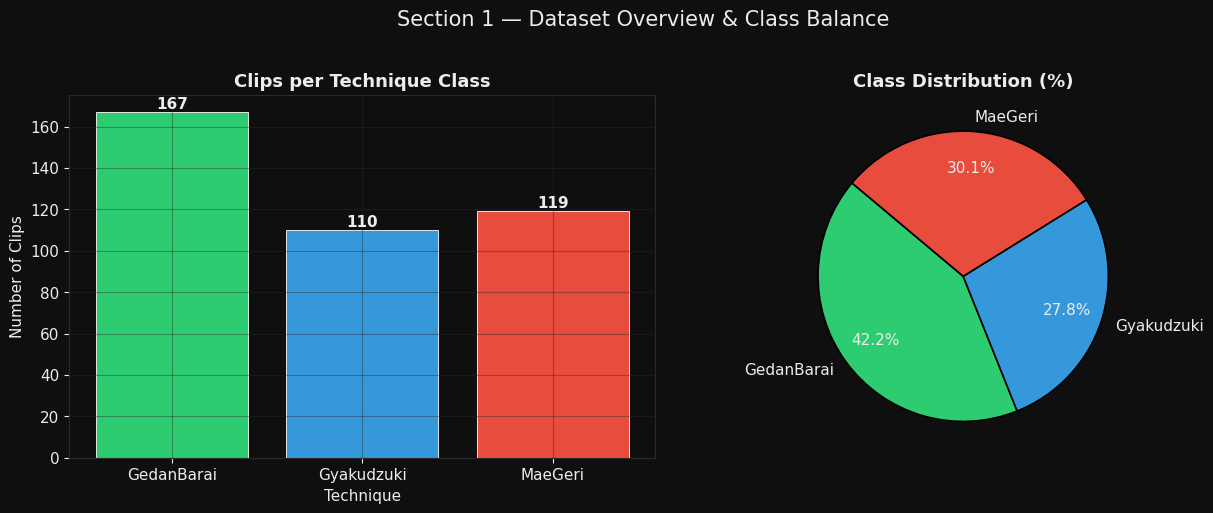


── Dataset Summary ──────────────────────────────────────────


,Clips,Frames,Share %
label,,,
GedanBarai,167.0,5010.0,42.2
Gyakudzuki,110.0,3300.0,27.8
MaeGeri,119.0,3570.0,30.1
TOTAL,396.0,11880.0,100.0


In [3]:
# ── Per-class clip counts ─────────────────────────────────────────────────────
clip_labels = ang_df.groupby('clip_id')['label'].first()
class_counts = clip_labels.value_counts()[CLASS_ORDER]
total_clips  = class_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle('Section 1 — Dataset Overview & Class Balance', fontsize=15, y=1.02)

# Bar chart
ax = axes[0]
bars = ax.bar(class_counts.index,
              class_counts.values,
              color=[PALETTE[c] for c in class_counts.index],
              edgecolor='white', linewidth=0.6)
ax.set_title('Clips per Technique Class')
ax.set_xlabel('Technique'); ax.set_ylabel('Number of Clips')
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(val)), ha='center', va='bottom', fontweight='bold')

# Pie chart
ax = axes[1]
wedges, texts, autos = ax.pie(
    class_counts.values,
    labels=class_counts.index,
    colors=[PALETTE[c] for c in class_counts.index],
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='black', linewidth=1.2)
)
ax.set_title('Class Distribution (%)')

plt.tight_layout()
plt.savefig(REPORT_DIR / 'sec1_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Clips':   class_counts.values,
    'Frames':  [len(ang_df[ang_df['label'] == c]) for c in class_counts.index],
    'Share %': (class_counts.values / total_clips * 100).round(1)
}, index=class_counts.index)
summary.loc['TOTAL'] = [summary['Clips'].sum(),
                         summary['Frames'].sum(),
                         100.0]
print('\n── Dataset Summary ──────────────────────────────────────────')
display(summary)

## 📊 Section 2 — Per-Clip Frame Count Distribution

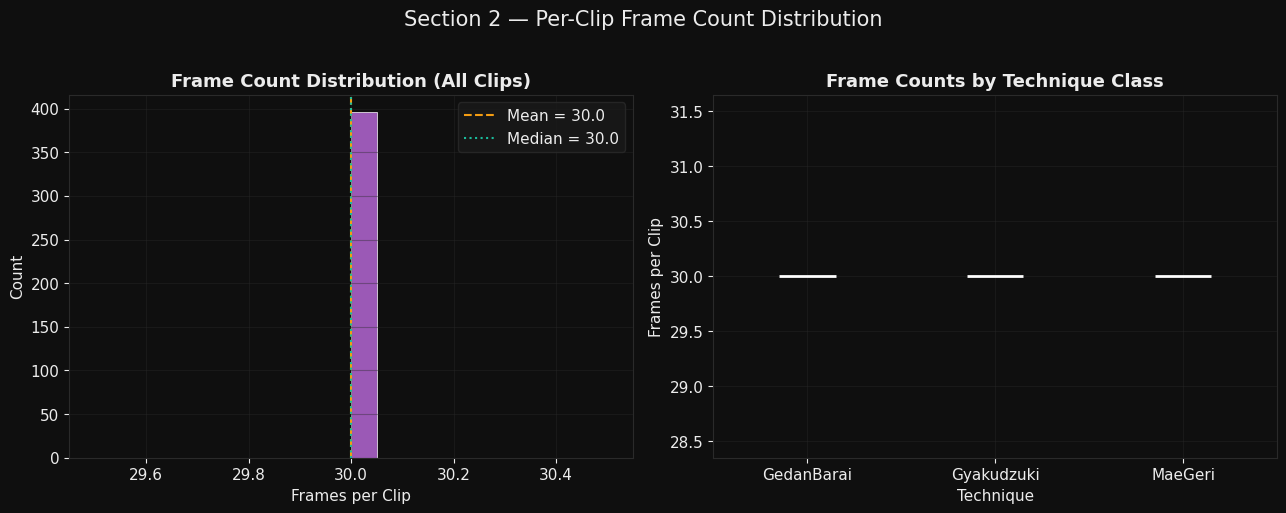


Min frames/clip: 30  |  Max: 30  |  Mean: 30.0  |  Std: 0.00


In [4]:
frame_counts = ang_df.groupby('clip_id').size()
frame_by_cls = ang_df.groupby(['clip_id', 'label']).size().reset_index()
frame_by_cls.columns = ['clip_id', 'label', 'frames']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle('Section 2 — Per-Clip Frame Count Distribution', fontsize=15, y=1.02)

# Overall histogram
ax = axes[0]
ax.hist(frame_counts.values, bins=20, color='#9b59b6', edgecolor='white', linewidth=0.5)
ax.axvline(frame_counts.mean(), color='#f39c12', linestyle='--',
           label=f'Mean = {frame_counts.mean():.1f}')
ax.axvline(frame_counts.median(), color='#1abc9c', linestyle=':',
           label=f'Median = {frame_counts.median():.1f}')
ax.set_title('Frame Count Distribution (All Clips)')
ax.set_xlabel('Frames per Clip'); ax.set_ylabel('Count')
ax.legend()

# Per-class box plot
ax = axes[1]
data_by_cls = [frame_by_cls[frame_by_cls['label'] == c]['frames'].values
               for c in CLASS_ORDER]
bp = ax.boxplot(data_by_cls,
                patch_artist=True,
                medianprops=dict(color='white', linewidth=2))
for patch, cls in zip(bp['boxes'], CLASS_ORDER):
    patch.set_facecolor(PALETTE[cls])
    patch.set_alpha(0.8)
ax.set_xticklabels(CLASS_ORDER)
ax.set_title('Frame Counts by Technique Class')
ax.set_xlabel('Technique'); ax.set_ylabel('Frames per Clip')

plt.tight_layout()
plt.savefig(REPORT_DIR / 'sec2_frame_counts.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nMin frames/clip: {frame_counts.min()}  |  '
      f'Max: {frame_counts.max()}  |  '
      f'Mean: {frame_counts.mean():.1f}  |  '
      f'Std: {frame_counts.std():.2f}')

## 📊 Section 3 — Feature Summary Statistics

In [5]:
# ── Angle feature statistics per class ───────────────────────────────────────
print('── Angle Feature Summary (all clips, sample of first 5 angles) ──────────')
ang_stats = ang_df.groupby('label')[ANGLE_COLS[:5]].describe().T
display(ang_stats.style.background_gradient(cmap='viridis', axis=None)
                       .format('{:.3f}'))

print('\n── Missing Values ──────────────────────────────────────────────────────')
mv_ang   = ang_df[ANGLE_COLS].isnull().sum()
mv_coord = coord_df[COORD_COLS].isnull().sum()
print(f'  Angles CSV  — missing cells: {mv_ang.sum()}')
print(f'  Coords CSV  — missing cells: {mv_coord.sum()}')
if mv_ang.sum() == 0 and mv_coord.sum() == 0:
    print('  ✅ No missing values detected — data is complete!')

── Angle Feature Summary (all clips, sample of first 5 angles) ──────────



── Missing Values ──────────────────────────────────────────────────────
  Angles CSV  — missing cells: 0
  Coords CSV  — missing cells: 0
  ✅ No missing values detected — data is complete!


## 📊 Section 4 — Feature Value Distributions

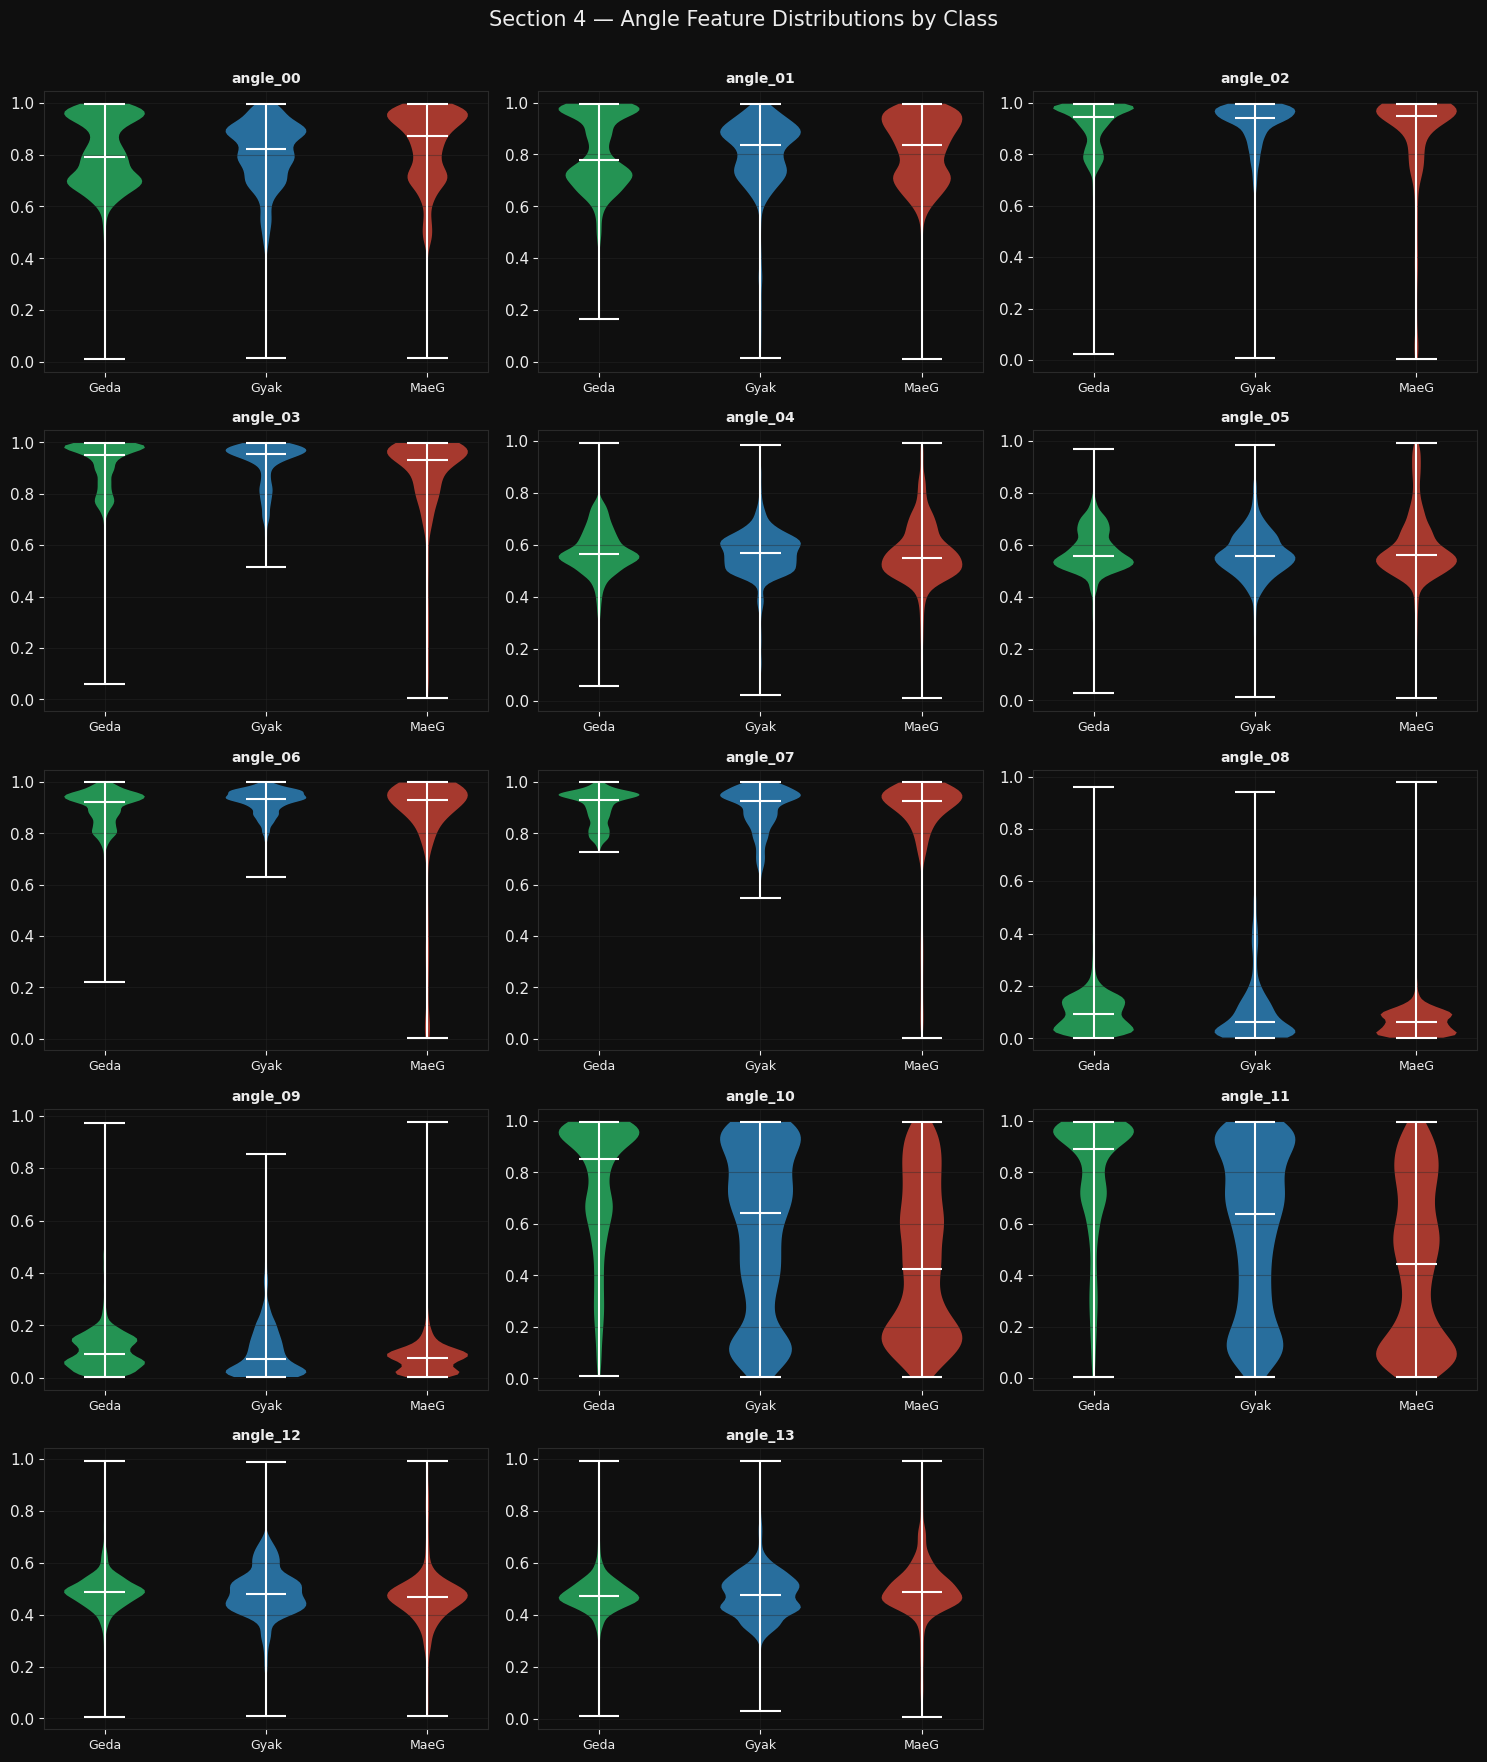

In [6]:
# ── Violin plots: each angle, split by class ──────────────────────────────────
n_angles = len(ANGLE_COLS)
n_cols   = 3
n_rows   = int(np.ceil(n_angles / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(5 * n_cols, 3.5 * n_rows),
                         squeeze=False)
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle('Section 4 — Angle Feature Distributions by Class',
             fontsize=15, y=1.005)

for idx, col in enumerate(ANGLE_COLS):
    row, c = divmod(idx, n_cols)
    ax = axes[row][c]
    data   = [ang_df[ang_df['label'] == cls][col].dropna().values
              for cls in CLASS_ORDER]
    parts  = ax.violinplot(data, showmedians=True)
    for i, (pc, cls) in enumerate(zip(parts['bodies'], CLASS_ORDER)):
        pc.set_facecolor(PALETTE[cls])
        pc.set_alpha(0.7)
    for part in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
        if part in parts:
            parts[part].set_color('white')
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels([c[:4] for c in CLASS_ORDER], fontsize=9)
    ax.set_title(col, fontsize=10)

# Hide unused subplots
for idx in range(n_angles, n_rows * n_cols):
    row, c = divmod(idx, n_cols)
    axes[row][c].set_visible(False)

plt.tight_layout()
plt.savefig(REPORT_DIR / 'sec4_angle_distributions.png', dpi=150,
            bbox_inches='tight')
plt.show()

## 📊 Section 5 — Angle Correlation Heatmap

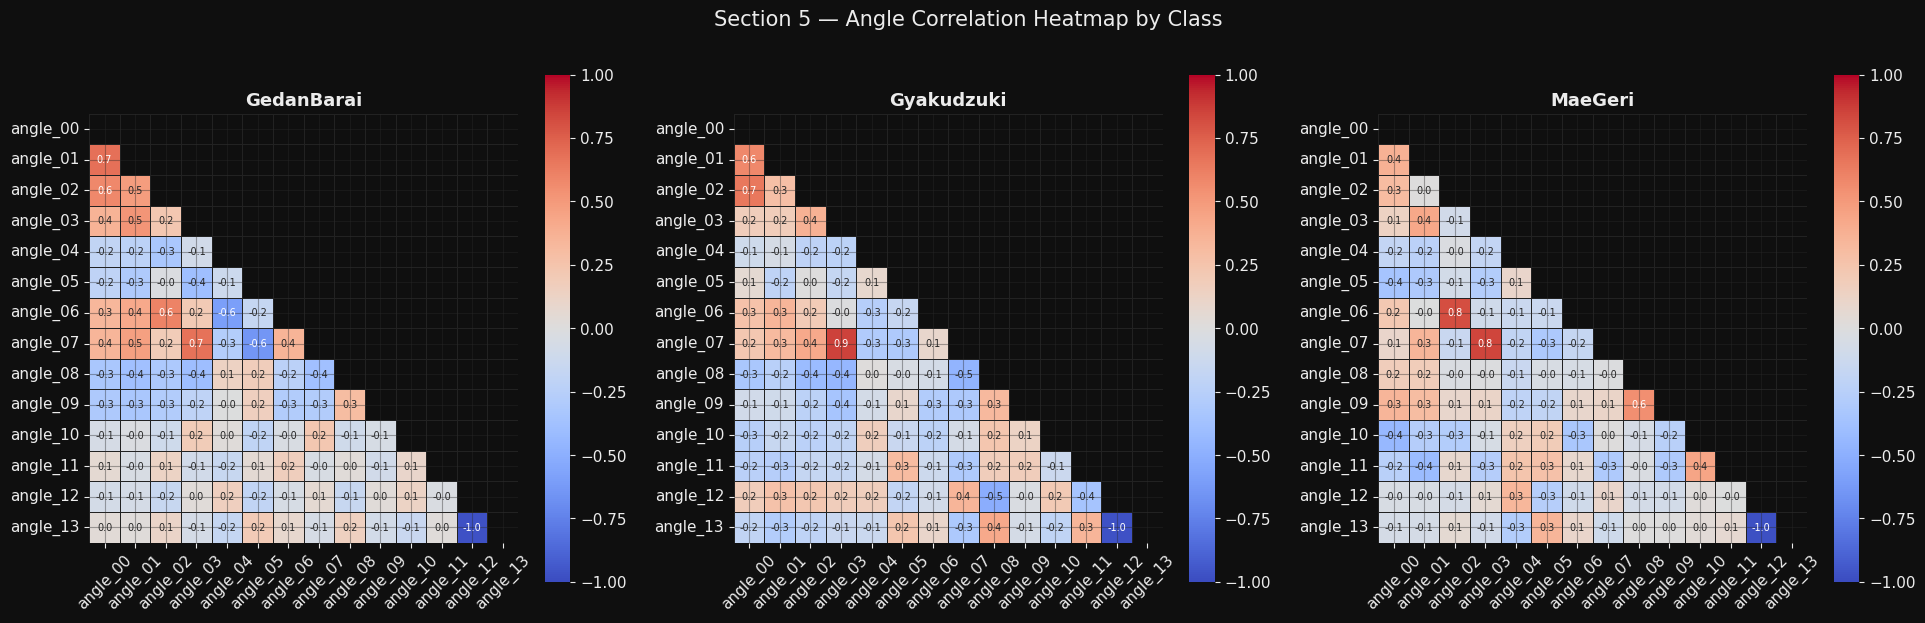

In [7]:
fig, axes = plt.subplots(1, len(CLASS_ORDER),
                         figsize=(6.5 * len(CLASS_ORDER), 6),
                         squeeze=False)
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle('Section 5 — Angle Correlation Heatmap by Class',
             fontsize=15, y=1.01)

for idx, cls in enumerate(CLASS_ORDER):
    ax   = axes[0][idx]
    corr = ang_df[ang_df['label'] == cls][ANGLE_COLS].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, ax=ax, mask=mask, cmap='coolwarm',
                annot=len(ANGLE_COLS) <= 14,
                fmt='.1f', linewidths=0.4, linecolor='#222',
                vmin=-1, vmax=1, square=True,
                annot_kws={'size': 7})
    ax.set_title(cls)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(REPORT_DIR / 'sec5_correlation_heatmaps.png', dpi=150,
            bbox_inches='tight')
plt.show()

## 📊 Section 6 — PCA Separability Visualisation

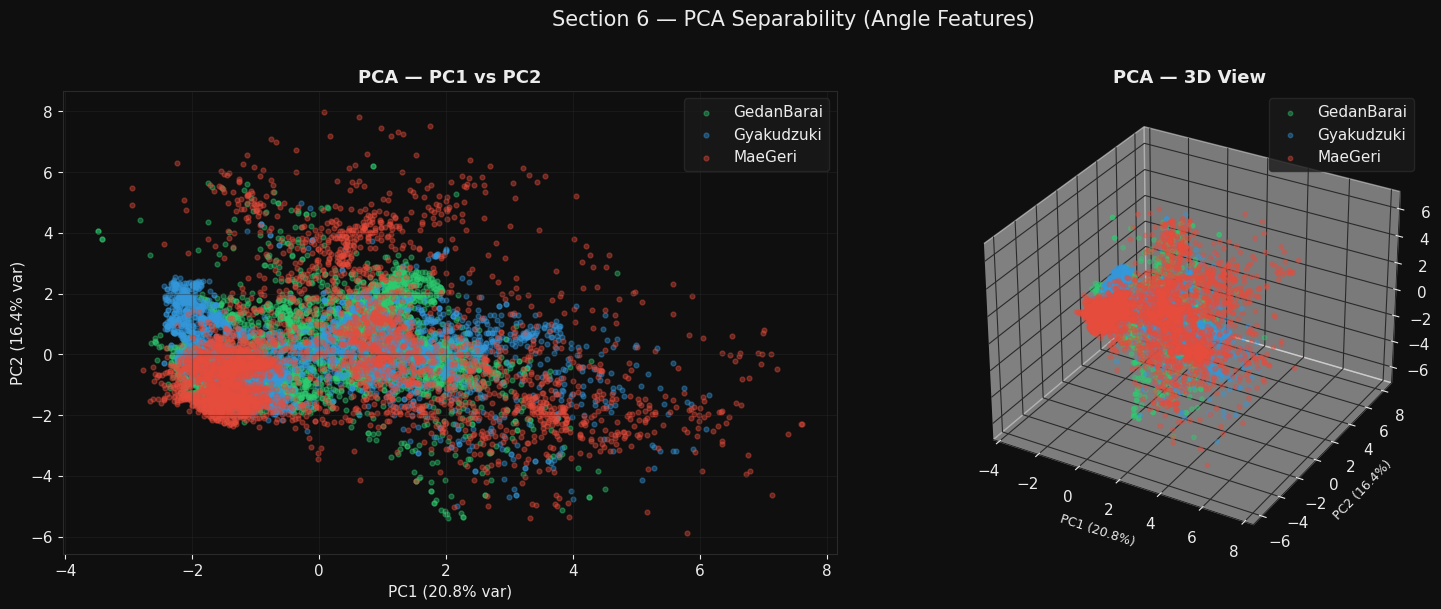


3 PCs explain 49.7% of total variance in angle features


In [8]:
# ── PCA on Angles ─────────────────────────────────────────────────────────────
X_raw = ang_df[ANGLE_COLS].fillna(0).values
y_raw = LabelEncoder().fit_transform(ang_df['label'].values)
label_names = ang_df['label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

pca3 = PCA(n_components=3)
pca3.fit(X_scaled)
X_pca = pca3.transform(X_scaled)

explained = pca3.explained_variance_ratio_

fig = plt.figure(figsize=(16, 6))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle('Section 6 — PCA Separability (Angle Features)', fontsize=15, y=1.01)

# ── 2D PCA ────────────────────────────────────────────────────────────────────
ax2d = fig.add_subplot(1, 2, 1)
for cls in CLASS_ORDER:
    mask = label_names == cls
    ax2d.scatter(X_pca[mask, 0], X_pca[mask, 1],
                 c=PALETTE[cls], label=cls, alpha=0.4, s=12)
ax2d.set_title('PCA — PC1 vs PC2')
ax2d.set_xlabel(f'PC1 ({explained[0]*100:.1f}% var)')
ax2d.set_ylabel(f'PC2 ({explained[1]*100:.1f}% var)')
ax2d.legend()

# ── 3D PCA ────────────────────────────────────────────────────────────────────
ax3d = fig.add_subplot(1, 2, 2, projection='3d')
ax3d.set_facecolor(BG_COLOR)
for cls in CLASS_ORDER:
    mask = label_names == cls
    ax3d.scatter(X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2],
                 c=PALETTE[cls], label=cls, alpha=0.4, s=10)
ax3d.set_title('PCA — 3D View')
ax3d.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)', fontsize=9)
ax3d.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)', fontsize=9)
ax3d.set_zlabel(f'PC3 ({explained[2]*100:.1f}%)', fontsize=9)
ax3d.legend()

plt.tight_layout()
plt.savefig(REPORT_DIR / 'sec6_pca.png', dpi=150, bbox_inches='tight')
plt.show()

total_var = sum(explained)
print(f'\n3 PCs explain {total_var*100:.1f}% of total variance in angle features')

## 📊 Section 7 — Temporal Signal Samples per Class

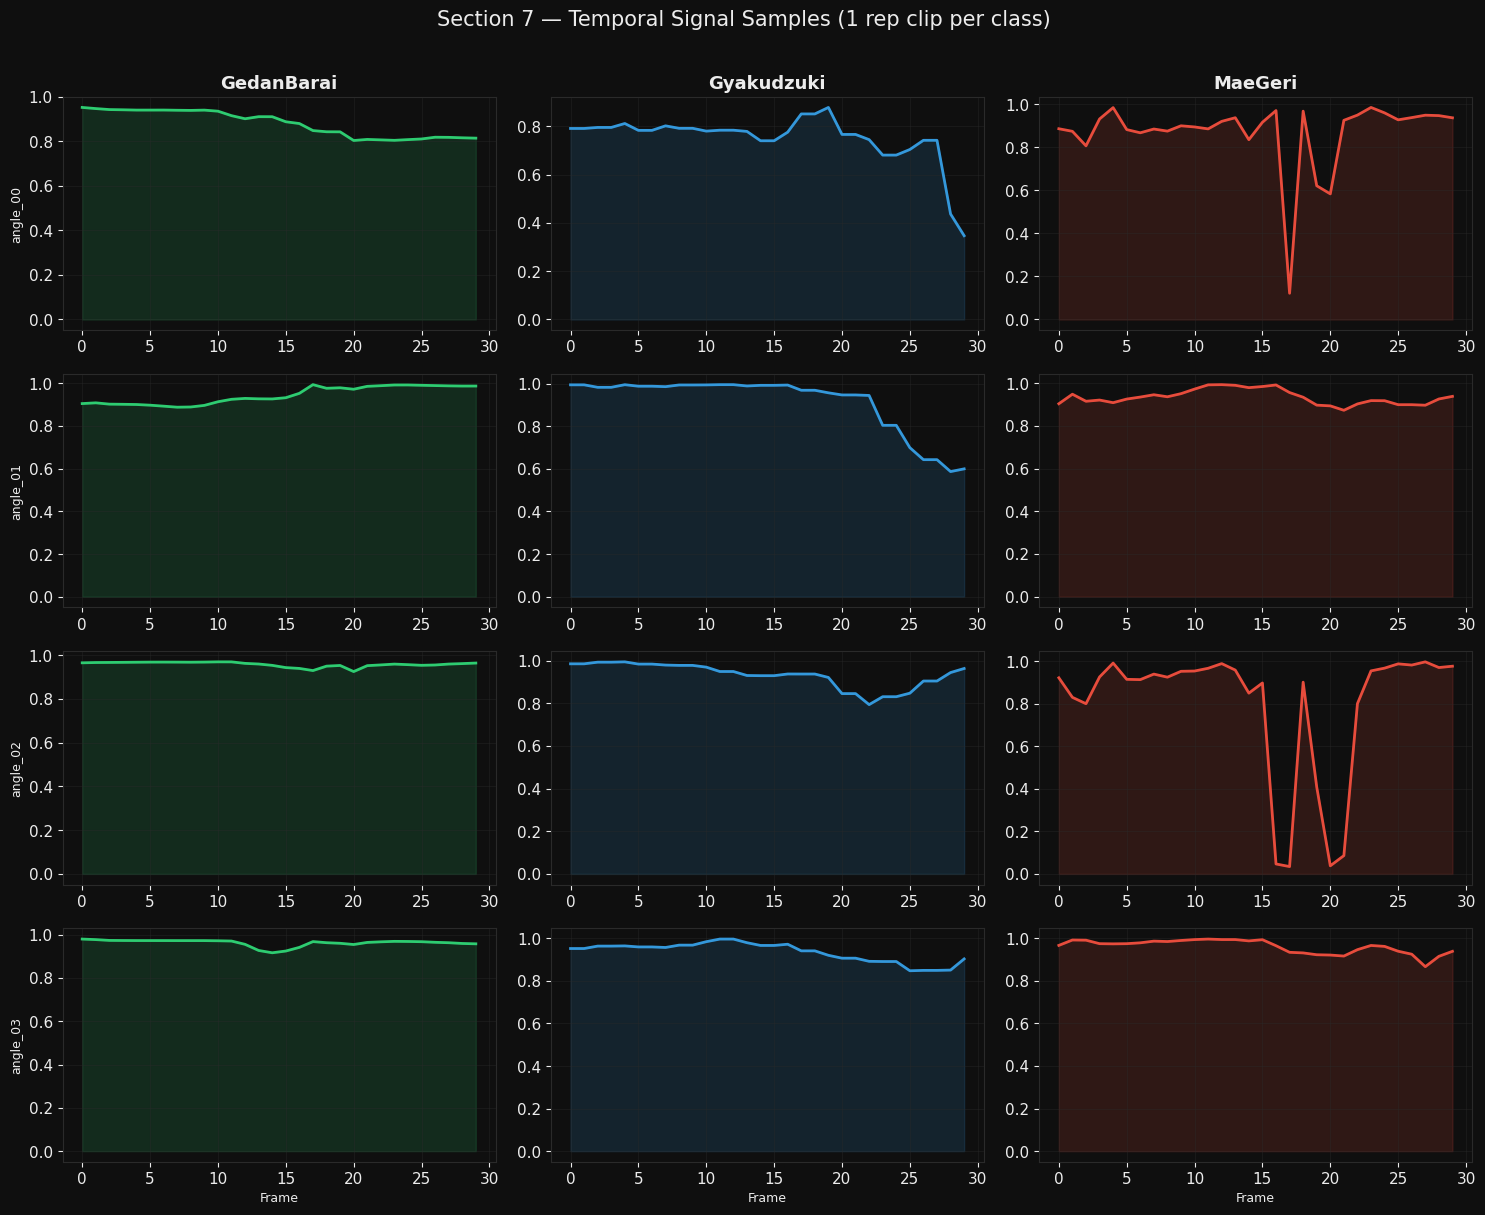

In [9]:
# Show one representative clip per class for each angle
SAMPLE_ANGLES = ANGLE_COLS[:4]   # show first 4 angles (adjust as needed)
SEQ_LEN       = 30

fig, axes = plt.subplots(len(SAMPLE_ANGLES), len(CLASS_ORDER),
                          figsize=(5 * len(CLASS_ORDER), 3 * len(SAMPLE_ANGLES)))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle('Section 7 — Temporal Signal Samples (1 rep clip per class)',
             fontsize=15, y=1.01)

for col_idx, cls in enumerate(CLASS_ORDER):
    # Pick the first clip for each class
    clip_ids = ang_df[ang_df['label'] == cls]['clip_id'].unique()
    sample   = ang_df[ang_df['clip_id'] == clip_ids[0]].sort_values('frame')

    # Resample to SEQ_LEN frames
    idx = np.linspace(0, len(sample)-1, SEQ_LEN).astype(int)
    sample = sample.iloc[idx]

    for row_idx, angle in enumerate(SAMPLE_ANGLES):
        ax = axes[row_idx][col_idx]
        ax.plot(sample[angle].values, color=PALETTE[cls], linewidth=2)
        ax.fill_between(range(SEQ_LEN), sample[angle].values,
                         alpha=0.15, color=PALETTE[cls])
        if row_idx == 0:
            ax.set_title(cls, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(angle, fontsize=9)
        ax.set_xlabel('Frame' if row_idx == len(SAMPLE_ANGLES)-1 else '', fontsize=9)

plt.tight_layout()
plt.savefig(REPORT_DIR / 'sec7_temporal_signals.png', dpi=150, bbox_inches='tight')
plt.show()

## 📊 Section 8 — Data Quality Report

In [10]:
print('═' * 62)
print('  🥋 AI Karate Sensei — DATA QUALITY REPORT')
print('═' * 62)

# ── Basic counts ──────────────────────────────────────────────────────────────
n_clips_ang   = ang_df['clip_id'].nunique()
n_clips_coord = coord_df['clip_id'].nunique()
n_frames_ang  = len(ang_df)
n_frames_crd  = len(coord_df)

print(f'\n  Angles CSV')
print(f'    Clips   : {n_clips_ang}')
print(f'    Rows    : {n_frames_ang:,}')
print(f'    Features: {len(ANGLE_COLS)}')
print(f'    NaN     : {ang_df[ANGLE_COLS].isnull().sum().sum()}')

print(f'\n  Coords CSV')
print(f'    Clips   : {n_clips_coord}')
print(f'    Rows    : {n_frames_crd:,}')
print(f'    Features: {len(COORD_COLS)}')
print(f'    NaN     : {coord_df[COORD_COLS].isnull().sum().sum()}')

# ── Frame-count consistency ────────────────────────────────────────────────────
frames_per_clip = ang_df.groupby('clip_id').size()
n_ok      = (frames_per_clip == 30).sum()
n_short   = (frames_per_clip <  30).sum()
n_long    = (frames_per_clip >  30).sum()

print(f'\n  Clips with exactly 30 frames : {n_ok}  ✅')
print(f'  Clips with < 30 frames       : {n_short}')
print(f'  Clips with > 30 frames       : {n_long}')

# ── Class balance ─────────────────────────────────────────────────────────────
clips_per_class = ang_df.groupby(['clip_id','label'])['label'].first().groupby('label').count()
imbalance_ratio = clips_per_class.max() / clips_per_class.min()

print(f'\n  Class counts: {dict(clips_per_class)}')
print(f'  Imbalance ratio (max/min): {imbalance_ratio:.2f}  '
      + ('✅ Balanced' if imbalance_ratio < 1.5 else '⚠️ Consider augmentation'))

# ── Infinite / extreme values ──────────────────────────────────────────────────
inf_ang   = np.isinf(ang_df[ANGLE_COLS].values).sum()
inf_coord = np.isinf(coord_df[COORD_COLS].values).sum()
print(f'\n  Inf values (Angles CSV) : {inf_ang}')
print(f'  Inf values (Coords CSV) : {inf_coord}')

print(f'\n  EDA PNG reports saved to:  {REPORT_DIR}')
print('═' * 62)

══════════════════════════════════════════════════════════════
  🥋 AI Karate Sensei — DATA QUALITY REPORT
══════════════════════════════════════════════════════════════

  Angles CSV
    Clips   : 396
    Rows    : 11,880
    Features: 14
    NaN     : 0

  Coords CSV
    Clips   : 396
    Rows    : 11,880
    Features: 132
    NaN     : 0

  Clips with exactly 30 frames : 396  ✅
  Clips with < 30 frames       : 0
  Clips with > 30 frames       : 0

  Class counts: {'GedanBarai': 167, 'Gyakudzuki': 110, 'MaeGeri': 119}
  Imbalance ratio (max/min): 1.52  ⚠️ Consider augmentation

  Inf values (Angles CSV) : 0
  Inf values (Coords CSV) : 0

  EDA PNG reports saved to:  D:\CS-Senior26'\GR\Karate_phase\Model_Build\eda_report
══════════════════════════════════════════════════════════════
